In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
DATA_PATH = Path("../data/processed")
MODEL_PATH = Path("../models")
IMAGE_PATH = Path("../images")

IMAGE_PATH.mkdir(
    exist_ok=True
)

In [4]:
X_test = scipy.sparse.load_npz(
    DATA_PATH / "X_test.npz"
)

y_test = np.load(
    DATA_PATH / "y_test.npy"
)

In [5]:
model = joblib.load(
    MODEL_PATH / "churn_catboost_tuned.pkl"
)

In [6]:
y_prob = model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_prob >= 0.5
).astype(int)

In [7]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

gini = (
    2 * roc_auc
    - 1
)

metrics = {
    "ROC_AUC": roc_auc,
    "GINI": gini,
    "Precision": precision_score(
        y_test,
        y_pred
    ),
    "Recall": recall_score(
        y_test,
        y_pred
    ),
    "F1": f1_score(
        y_test,
        y_pred
    )
}

metricsroc_auc = roc_auc_score(
    y_test,
    y_prob
)

gini = (
    2 * roc_auc
    - 1
)

metrics = {
    "ROC_AUC": roc_auc,
    "GINI": gini,
    "Precision": precision_score(
        y_test,
        y_pred
    ),
    "Recall": recall_score(
        y_test,
        y_pred
    ),
    "F1": f1_score(
        y_test,
        y_pred
    )
}

metrics

{'ROC_AUC': 0.8396187833577504,
 'GINI': 0.6792375667155008,
 'Precision': 0.4942528735632184,
 'Recall': 0.8048128342245989,
 'F1': 0.612410986775178}

In [8]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



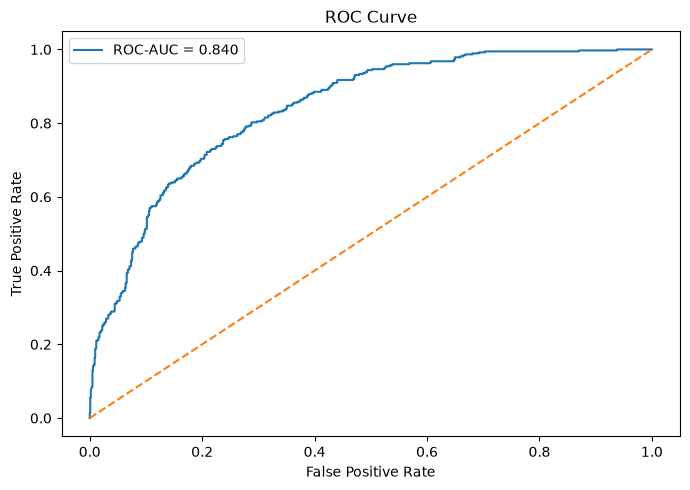

In [9]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    IMAGE_PATH / "roc_curve.png",
    dpi=300
)

plt.show()

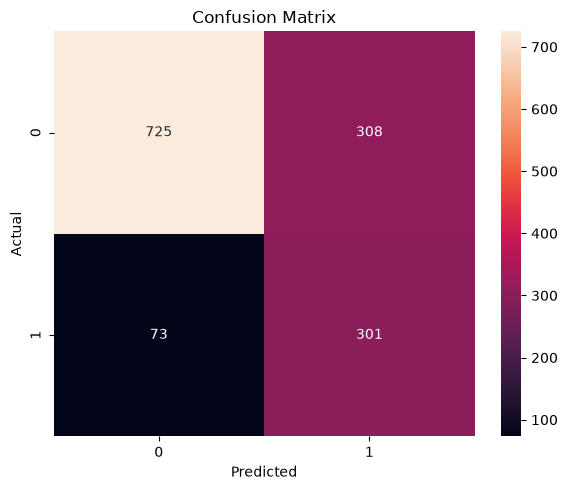

In [10]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    IMAGE_PATH / "confusion_matrix.png",
    dpi=300
)

plt.show()

In [11]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    prediction = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            prediction,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.349191,0.981283,0.515088
1,0.15,0.365482,0.962567,0.529801
2,0.20,0.386853,0.959893,0.551459
3,0.25,0.408140,0.938503,0.568882
4,0.30,0.423457,0.917112,0.579392
5,0.35,0.436435,0.890374,0.585752
6,0.40,0.453652,0.863636,0.594843
7,0.45,0.468468,0.834225,0.600000
8,0.50,0.494253,0.804813,0.612411
9,0.55,0.523897,0.762032,0.620915


In [12]:
best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_f1_row

Threshold    0.600000
Precision    0.556250
Recall       0.713904
F1           0.625293
Name: 10, dtype: float64

In [13]:
business_threshold_df = threshold_df[
    threshold_df["Precision"] >= 0.50
]

business_threshold_df.sort_values(
    "Recall",
    ascending=False
)

,Threshold,Precision,Recall,F1
9,0.55,0.523897,0.762032,0.620915
10,0.60,0.556250,0.713904,0.625293
11,0.65,0.588517,0.657754,0.621212
12,0.70,0.634006,0.588235,0.610264
13,0.75,0.658088,0.478610,0.554180
14,0.80,0.666667,0.347594,0.456942
15,0.85,0.782258,0.259358,0.389558
16,0.90,0.905660,0.128342,0.224824


In [14]:
business_threshold = (
    business_threshold_df
    .sort_values(
        "Recall",
        ascending=False
    )
    .iloc[0]["Threshold"]
)

business_threshold

np.float64(0.5500000000000002)

In [15]:
business_pred = (
    y_prob >= business_threshold
).astype(int)

In [16]:
business_metrics = {

    "Threshold":
        business_threshold,

    "Precision":
        precision_score(
            y_test,
            business_pred
        ),

    "Recall":
        recall_score(
            y_test,
            business_pred
        ),

    "F1":
        f1_score(
            y_test,
            business_pred
        )
}

business_metrics

{'Threshold': np.float64(0.5500000000000002),
 'Precision': 0.5238970588235294,
 'Recall': 0.7620320855614974,
 'F1': 0.6209150326797386}

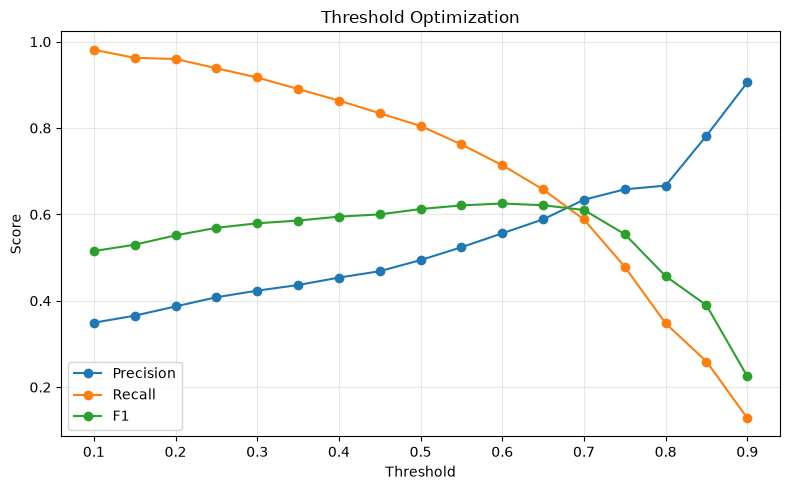

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    IMAGE_PATH / "threshold_optimization.png",
    dpi=300
)

plt.show()

In [18]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

ks_values = tpr - fpr

ks_index = np.argmax(
    ks_values
)

ks_statistic = ks_values[
    ks_index
]

ks_threshold = thresholds[
    ks_index
]

print(
    f"KS Statistic: {ks_statistic:.4f}"
)

print(
    f"KS Threshold: {ks_threshold:.4f}"
)

KS Statistic: 0.5168
KS Threshold: 0.5642


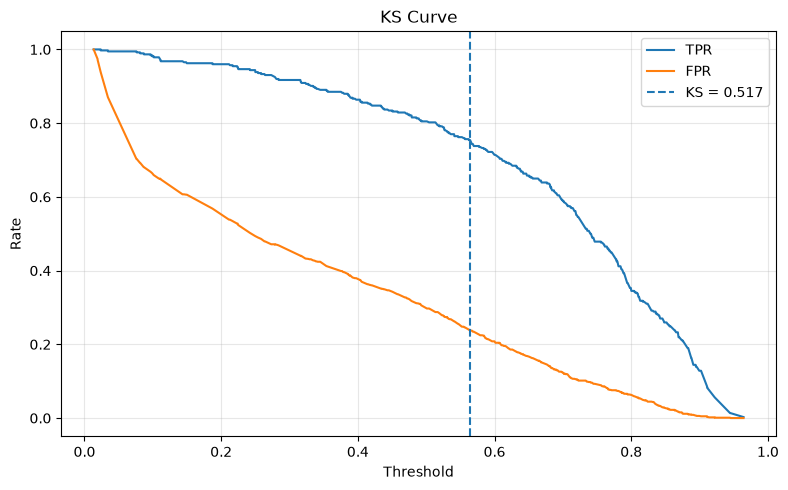

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    tpr,
    label="TPR"
)

plt.plot(
    thresholds,
    fpr,
    label="FPR"
)

plt.axvline(
    ks_threshold,
    linestyle="--",
    label=f"KS = {ks_statistic:.3f}"
)

plt.xlabel("Threshold")
plt.ylabel("Rate")

plt.title(
    "KS Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    IMAGE_PATH / "ks_curve.png",
    dpi=300
)

plt.show()

In [20]:
threshold_df.to_csv(
    DATA_PATH / "threshold_analysis.csv",
    index=False
)


pd.DataFrame([metrics]).to_csv(
    DATA_PATH / "final_metrics.csv",
    index=False
)